# Loan Approval Prediction

This project aims to predict whether a loan will be approved or not based on applicant details using Machine Learning techniques

## Problem Statement

The goal of this project is to build a machine learning model that can predict loan approval status based on various applicant features such as income, loan amount, CIBIL score, and other factors

This can help financial institutions automate decision making and reduce manual effort

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv('/content/drive/MyDrive/Datasets/loan_approval_dataset.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [5]:
#Statistical summary of the dataset
data.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:
# It is use for displaying the float values in 2 decimal places in statistical summary
pd.set_option('display.float_format','{:.2f}'.format)

In [7]:
data.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.00,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.50,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.00,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.00,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.00,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.00,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.00,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [8]:
data

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [ ]:
#ab dekho info function mai blank spaces hai jisko hum strip function se remove karenge
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
data.columns
#space hai dikha raha hai

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [11]:
data.columns =data.columns.str.strip()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
data['education'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [ ]:
data['education'] = data['education'].str.strip()
data['self_employed'] = data['self_employed'].str.strip()
data['loan_status'] = data['loan_status'].str.strip()

In [ ]:
data['education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [ ]:
#what percentage of applicate get loan approval vs not approval
data['loan_status'].value_counts()

,count
loan_status,
Approved,2656
Rejected,1613


In [ ]:
data['loan_status'].value_counts(normalize=True) * 100

,proportion
loan_status,
Approved,62.22
Rejected,37.78


In [ ]:
data.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [ ]:
data['loan_id'] = data['loan_id'].astype(str)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   object
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(9), object(4)
memory usage: 433.7+ KB


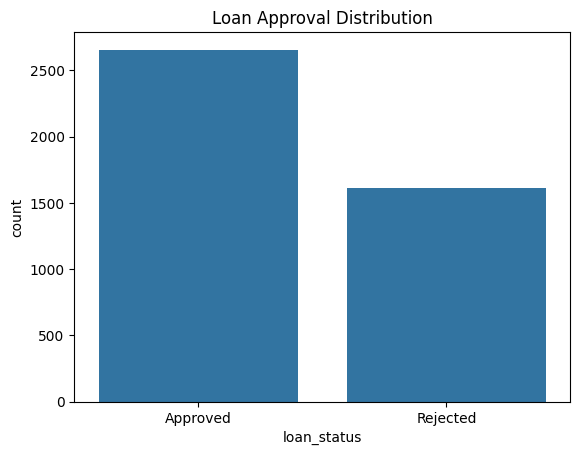

In [21]:
#chech the data balance hai ya nahi

sns.countplot(x='loan_status',data=data)
plt.title("Loan Approval Distribution")
plt.show()

This data is imbalanced

In [ ]:
data['loan_status'].value_counts()

,count
loan_status,
Approved,2656
Rejected,1613


employment type effect on loan approval

In [ ]:
data['self_employed'].value_counts()

,count
self_employed,
Yes,2150
No,2119


In [24]:
data.groupby(['self_employed','loan_status'])['loan_status'].count()

self_employed  loan_status
No             Approved       1318
               Rejected        801
Yes            Approved       1338
               Rejected        812
Name: loan_status, dtype: int64

In [25]:
emp_status= data.groupby(['self_employed','loan_status'])['loan_status'].count().unstack()

In [ ]:
emp_status 

loan_status,Approved,Rejected
self_employed,,
No,1318,801
Yes,1338,812


In [ ]:
emp_status['Total']  = emp_status['Approved'] + emp_status['Rejected']

In [ ]:
emp_status

loan_status,Approved,Rejected,Total
self_employed,,,
No,1318,801,2119
Yes,1338,812,2150


In [29]:
emp_status['Approved_%'] = (emp_status['Approved'] / emp_status['Total']) * 100

In [30]:
emp_status

loan_status,Approved,Rejected,Total,Approved_%
self_employed,,,,
No,1318,801,2119,62.20
Yes,1338,812,2150,62.23


<Axes: xlabel='self_employed'>

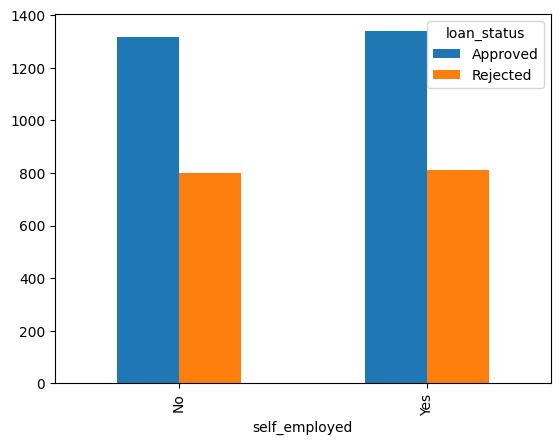

In [31]:
emp_status[['Approved','Rejected']].plot(kind='bar')

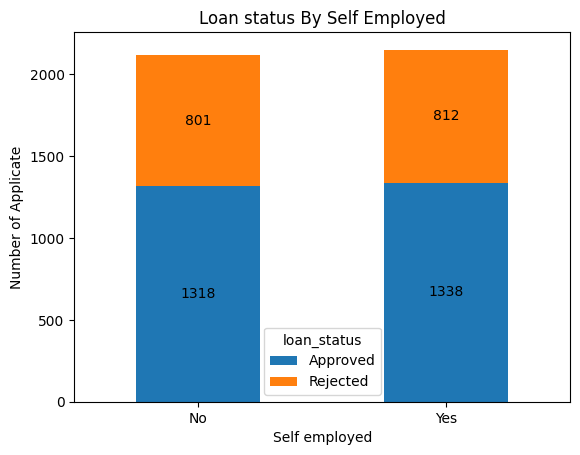

In [32]:
ax = emp_status[['Approved','Rejected']].plot(kind='bar',stacked=True)
plt.title('Loan status By Self Employed')
plt.xlabel('Self employed')
plt.ylabel('Number of Applicate')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container,label_type = 'center')
plt.show()

Graduates ko Jayada loan Approvel milti hai??

In [33]:
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
data['education'].value_counts()

,count
education,
Graduate,2144
Not Graduate,2125


In [35]:
education_status  = data.groupby(['education','loan_status'])['loan_status'].count().unstack()

In [ ]:
education_status

loan_status,Approved,Rejected
education,,
Graduate,1339,805
Not Graduate,1317,808


In [ ]:
education_status['Total'] = education_status['Approved']  + education_status['Rejected']

In [ ]:
education_status

loan_status,Approved,Rejected,Total
education,,,
Graduate,1339,805,2144
Not Graduate,1317,808,2125


In [ ]:
education_status['Approved_%']= (education_status['Approved'] / education_status['Total']) * 100

In [ ]:
education_status

loan_status,Approved,Rejected,Total,Approved_%
education,,,,
Graduate,1339,805,2144,62.45
Not Graduate,1317,808,2125,61.98


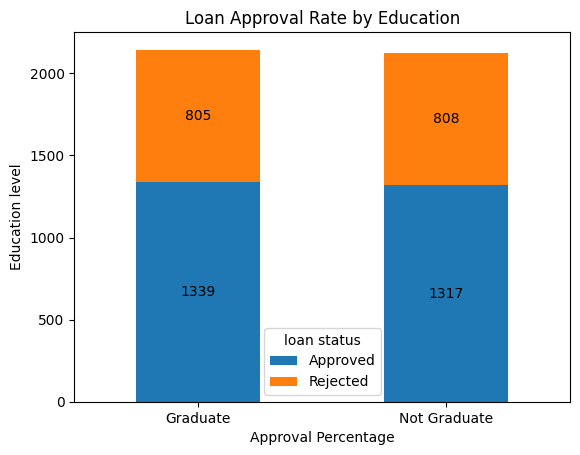

In [41]:
ax1 = education_status[['Approved','Rejected']].plot(kind="bar",stacked=True)
plt.title("Loan Approval Rate by Education")
plt.xlabel("Approval Percentage")
plt.ylabel("Education level")
plt.xticks(rotation=0)
plt.legend(title='loan status')

for container in ax1.containers:
    ax1.bar_label(container,label_type='center')


plt.show()

does having  more dependents reduce approval chances

In [ ]:
data['no_of_dependents'].value_counts()

,count
no_of_dependents,
4,752
3,727
0,712
2,708
1,697
5,673


In [ ]:
depended_status = data.groupby(['no_of_dependents','loan_status'])['loan_status'].count().unstack()
depended_status

loan_status,Approved,Rejected
no_of_dependents,,
0,457,255
1,430,267
2,441,267
3,457,270
4,465,287
5,406,267


In [ ]:
depended_status['Total'] = depended_status['Approved'] + depended_status['Rejected']

In [45]:
depended_status

loan_status,Approved,Rejected,Total
no_of_dependents,,,
0,457,255,712
1,430,267,697
2,441,267,708
3,457,270,727
4,465,287,752
5,406,267,673


In [ ]:
depended_status['Approval_%'] = (depended_status['Approved'] / depended_status['Total']) * 100  

In [47]:
depended_status

loan_status,Approved,Rejected,Total,Approval_%
no_of_dependents,,,,
0,457,255,712,64.19
1,430,267,697,61.69
2,441,267,708,62.29
3,457,270,727,62.86
4,465,287,752,61.84
5,406,267,673,60.33


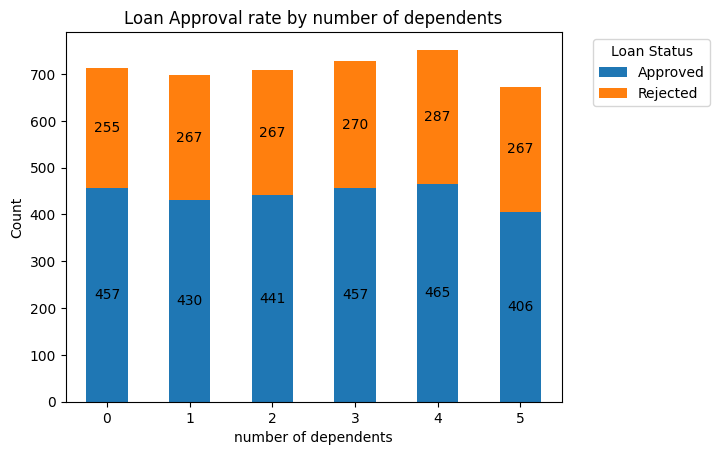

In [48]:
ax2 = depended_status[['Approved','Rejected']].plot(kind='bar',stacked=True)
plt.title("Loan Approval rate by number of dependents")
plt.xlabel("number of dependents")
plt.ylabel("Count")
plt.legend(title="Loan Status",bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)

for container in ax2.containers:
    ax2.bar_label(container,label_type='center')
plt.show()

What is the relationship between applicant income and loan approval

In [ ]:
data['income_annum'].describe()

,income_annum
count,4269.00
mean,5059123.92
std,2806839.83
min,200000.00
25%,2700000.00
50%,5100000.00
75%,7500000.00
max,9900000.00


In [50]:
x = data.groupby(by=['loan_status']).mean(numeric_only=True)['income_annum']
x

,income_annum
loan_status,
Approved,5025903.61
Rejected,5113825.17


In [51]:
type(x)

pandas.core.series.Series

<Axes: xlabel='loan_status'>

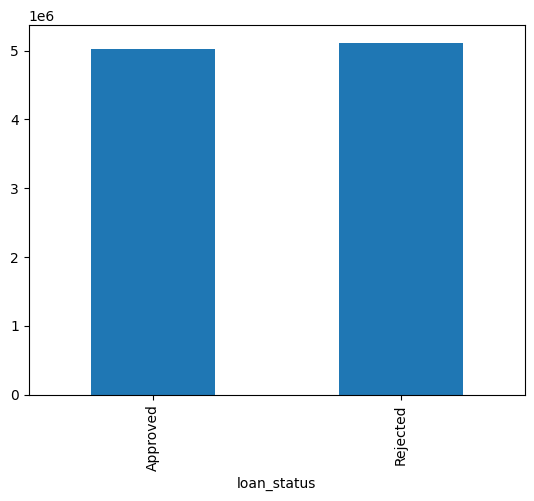

In [52]:
x.plot(kind='bar')

How does loan amount very between approved and rejected  loans?

In [ ]:
data['loan_amount'].describe()

,loan_amount
count,4269.00
mean,15133450.46
std,9043362.98
min,300000.00
25%,7700000.00
50%,14500000.00
75%,21500000.00
max,39500000.00


In [ ]:
data.groupby(by=['loan_status']).mean(numeric_only=True)['loan_amount']

,loan_amount
loan_status,
Approved,15247251.51
Rejected,14946063.24


In [ ]:
approved_amount = data[data['loan_status'] == 'Approved']['loan_amount']
approved_amount

,loan_amount
0,29900000
6,33000000
8,2200000
10,11200000
13,31500000
...,...
4261,7500000
4263,12700000
4265,11300000
4267,12800000


In [ ]:
rejected_amount = data[data['loan_status']== 'Rejected']['loan_amount']
rejected_amount

,loan_amount
1,12200000
2,29700000
3,30700000
4,24200000
5,13500000
...,...
4258,22600000
4259,11500000
4262,3000000
4264,2300000


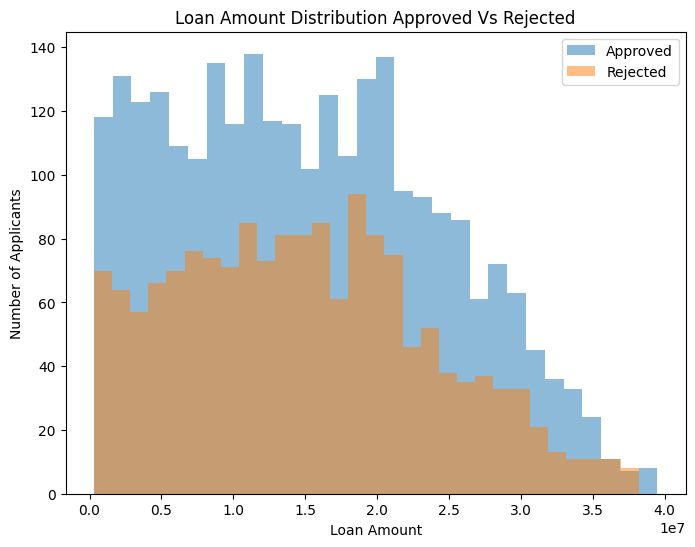

In [57]:
#plot histogram
plt.figure(figsize=(8,6))

plt.hist(approved_amount,bins=30,alpha=0.5,label="Approved")
plt.hist(rejected_amount,bins=30,alpha=0.5,label="Rejected")

plt.title("Loan Amount Distribution Approved Vs Rejected")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")
plt.legend()
plt.show()

Does CIBIL score  strongly influence loan approval?

In [ ]:
data['cibil_score'].describe()

,cibil_score
count,4269.00
mean,599.94
std,172.43
min,300.00
25%,453.00
50%,600.00
75%,748.00
max,900.00


In [59]:
data.groupby(('loan_status'))['cibil_score'].mean()

,cibil_score
loan_status,
Approved,703.46
Rejected,429.47


In [ ]:
approved_cibil = data[data['loan_status'] == 'Approved']['cibil_score']
rejected_cibil = data[data['loan_status'] == 'Rejected']['cibil_score']

In [ ]:
approved_cibil


,cibil_score
0,778
6,678
8,782
10,547
13,679
...,...
4261,881
4263,865
4265,559
4267,780


In [ ]:
rejected_cibil

,cibil_score
1,417
2,506
3,467
4,382
5,319
...,...
4258,346
4259,509
4262,540
4264,317


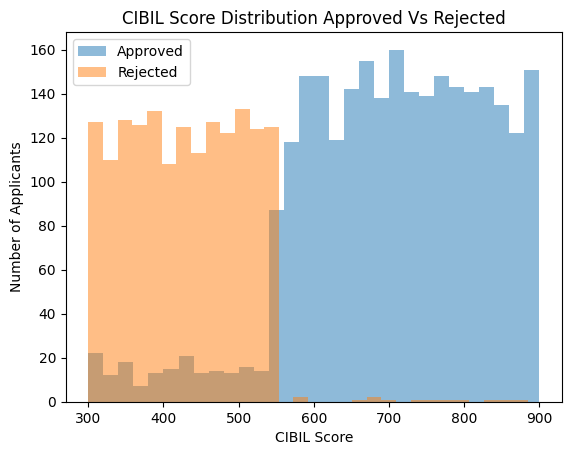

In [63]:
plt.hist(approved_cibil,bins=30,alpha=0.5,label="Approved")
plt.hist(rejected_cibil,bins=30,alpha=0.5,label="Rejected")

plt.title("CIBIL Score Distribution Approved Vs Rejected")
plt.xlabel("CIBIL Score")
plt.ylabel("Number of Applicants")
plt.legend()
plt.show()

Compare Applicant income Vs Loan Amount

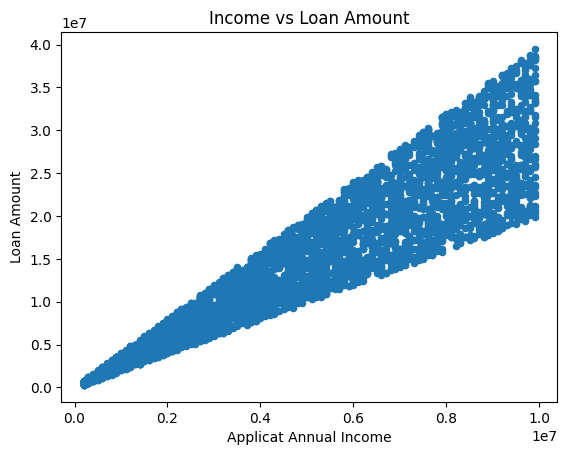

In [64]:
data.plot(x='income_annum',y='loan_amount',kind='scatter')

plt.xlabel("Applicat Annual Income")
plt.ylabel("Loan Amount")
plt.title("Income vs Loan Amount")
plt.show()

Show Correlation heatmap of numerical feture

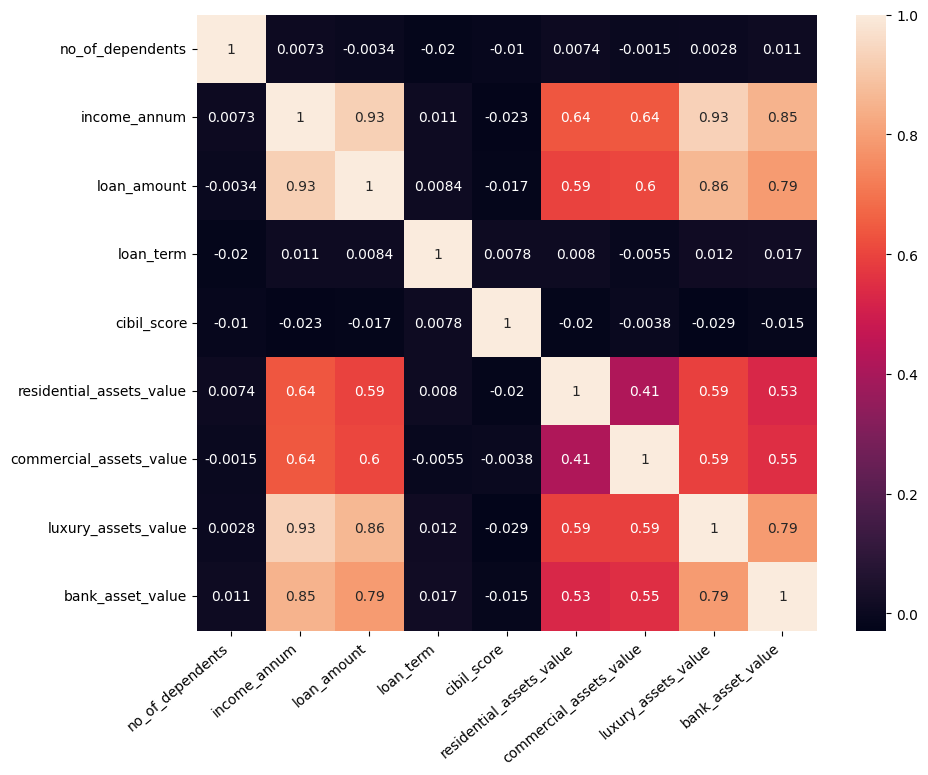

In [65]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True),annot=True)
plt.xticks(rotation=40,ha='right')
plt.show()

Detect Outliers

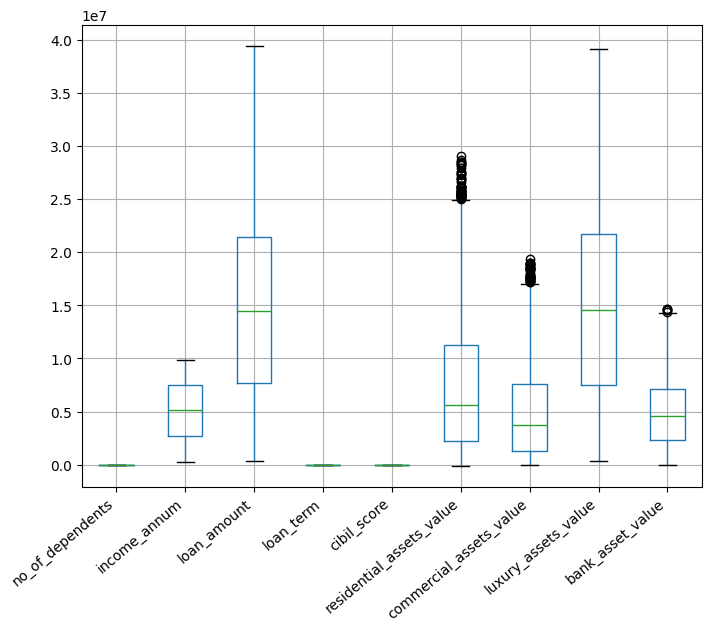

In [66]:
plt.figure(figsize=(8,6))
data.boxplot()
plt.xticks(rotation=40,ha='right')
plt.show()

In [67]:
data.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [68]:
R_Q1 = data['residential_assets_value'].quantile(0.25)
R_Q3 = data['residential_assets_value'].quantile(0.75)

#Calculate the interquartile range (IQR)
IQR = R_Q3 - R_Q1
IQR

np.float64(9100000.0)

In [ ]:
lower_limit = R_Q1 - 1.5 * IQR
upper_limit = R_Q3 + 1.5 * IQR

In [70]:
data = data[(data['residential_assets_value'] >=lower_limit) & (data['residential_assets_value'] <= upper_limit)]
data

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


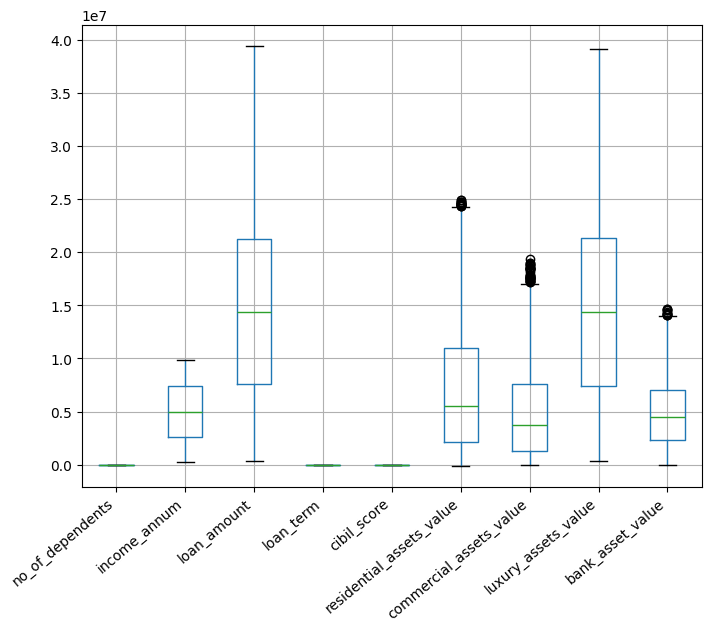

In [71]:
plt.figure(figsize=(8,6))
data.boxplot()
plt.xticks(rotation=40,ha='right')
plt.show()

In [72]:
#Calculate commerical assets value outliers
C_Q1 = data['commercial_assets_value'].quantile(0.25)
C_Q3 = data['commercial_assets_value'].quantile(0.75)

IQR = C_Q3  - C_Q1
IQR

np.float64(6300000.0)

In [ ]:
C_lower_limit = C_Q1 - 1.5 * IQR
C_upper_limit = C_Q3 + 1.5 * IQR

In [ ]:
data = data[(data['commercial_assets_value'] >= C_lower_limit) & (data['commercial_assets_value'] <= C_upper_limit)]
data

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


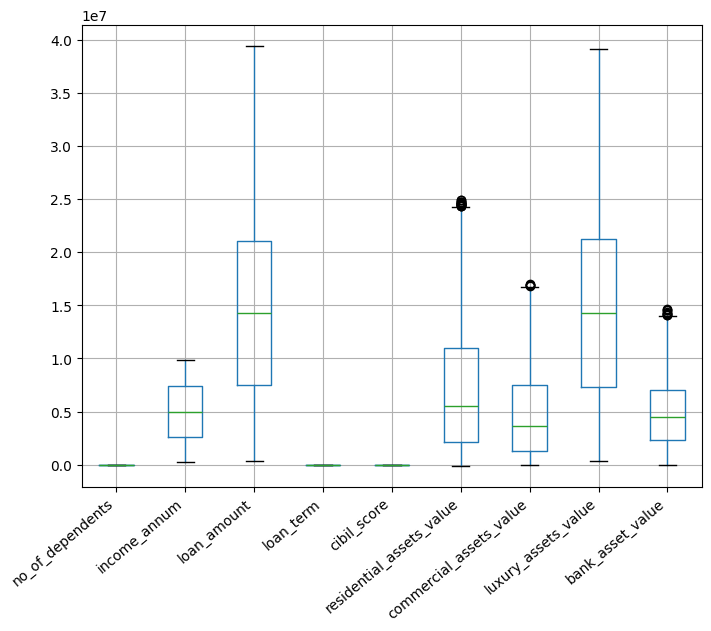

In [75]:
plt.figure(figsize=(8,6))
data.boxplot()
plt.xticks(rotation=40,ha='right')
plt.show()

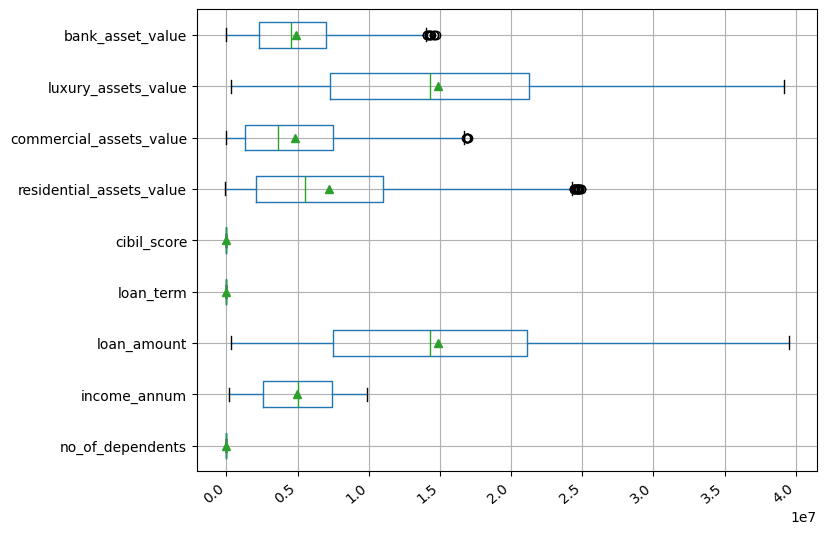

In [76]:
plt.figure(figsize=(8,6))
data.boxplot(showmeans=True,vert=False)
plt.xticks(rotation=40,ha='right')
plt.show()

In [ ]:
data = data.drop('loan_id',axis=1)
data

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [78]:
data['loan_status'] = data['loan_status'].map({'Approved': 1,'Rejected' : 0})
data

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


In [79]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

lr = LabelEncoder()

data['self_employed'] = lr.fit_transform(data['self_employed'])

In [ ]:
data.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,Graduate,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0


One Hot encoding

In [ ]:
data = pd.get_dummies(data, columns=['education'], dtype=int)


In [ ]:
data = data.astype(int)

In [ ]:
data.head()

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,0,1
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,1,0
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,1,0
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,0,1
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,1,0


Scale munerical feature before model training

Model Building

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
X = data.drop('loan_status',axis=1)
y = data['loan_status']

In [ ]:
X

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,1
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1,0
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1,0
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,1
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1000000,2300000,12,317,2800000,500000,3300000,800000,1,0
4265,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,0,1
4266,2,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,1
4267,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,0,1


In [87]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

models = {
      "Logistic Regression" : LogisticRegression(max_iter=1000),
      "Decision Tree" : DecisionTreeClassifier(),
      "Random Forest" : RandomForestClassifier()
}

for name,model in models.items():
    model.fit(X_train,y_train)
    preds = model.predict(X_test)
    print(name,"Accuracy",accuracy_score(y_test,preds))

Logistic Regression Accuracy 0.7968936678614098
Decision Tree Accuracy 0.9713261648745519
Random Forest Accuracy 0.978494623655914


In [88]:
X = data.drop('loan_status',axis=1)
y = data['loan_status']

In [89]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [90]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42)


In [91]:
rf_model.fit(X_train,y_train)


RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [92]:
y_pred = rf_model.predict(X_test)


In [93]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print("Accuracy : ",accuracy_score(y_test,y_pred) * 100,"%")
print("\nClassification Report: ",classification_report(y_test,y_pred))
print("\nConfusion Matrix: ",confusion_matrix(y_test,y_pred))



Accuracy :  97.2520908004779 %

Classification Report:                precision    recall  f1-score   support

           0       0.97      0.95      0.96       316
           1       0.97      0.98      0.98       521

    accuracy                           0.97       837
   macro avg       0.97      0.97      0.97       837
weighted avg       0.97      0.97      0.97       837


Confusion Matrix:  [[301  15]
 [  8 513]]


In [94]:
feature_importance = pd.Series(rf_model.feature_importances_,index=X.columns).sort_values(ascending=False)
feature_importance

,0
cibil_score,0.83
loan_term,0.06
loan_amount,0.02
luxury_assets_value,0.02
income_annum,0.01
residential_assets_value,0.01
commercial_assets_value,0.01
bank_asset_value,0.01
no_of_dependents,0.01
self_employed,0.00


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 [Text(0, 0, 'cibil_score'),
  Text(1, 0, 'loan_term'),
  Text(2, 0, 'loan_amount'),
  Text(3, 0, 'luxury_assets_value'),
  Text(4, 0, 'income_annum'),
  Text(5, 0, 'residential_assets_value'),
  Text(6, 0, 'commercial_assets_value'),
  Text(7, 0, 'bank_asset_value'),
  Text(8, 0, 'no_of_dependents'),
  Text(9, 0, 'self_employed'),
  Text(10, 0, 'education_Not Graduate'),
  Text(11, 0, 'education_Graduate')])

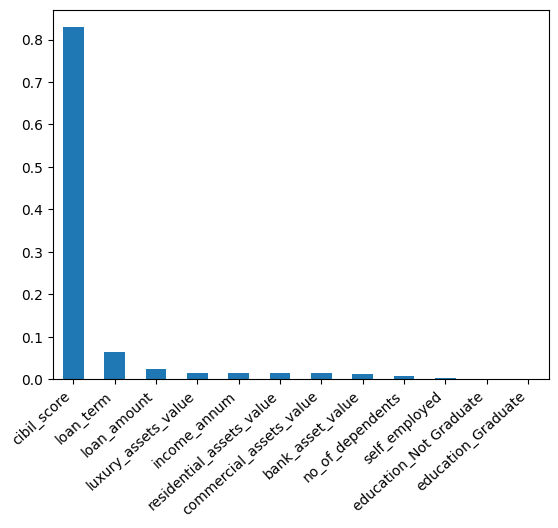

In [95]:
import matplotlib.pyplot as plt
feature_importance.plot(kind='bar')
plt.xticks(rotation=42,ha='right')

In [96]:
print(X_test.head())

print(y_test.head())

      no_of_dependents  self_employed  income_annum  loan_amount  loan_term  \
2767                 0              1       2600000      7500000          2   
1370                 4              1       8900000     34000000         20   
1139                 1              1       6400000     17300000         10   
1516                 5              0       8800000     21600000         18   
3684                 4              0       1300000      4600000         10   

      cibil_score  residential_assets_value  commercial_assets_value  \
2767          853                   4200000                  3900000   
1370          415                  13500000                  3100000   
1139          879                  10000000                  1100000   
1516          613                  15400000                 12100000   
3684          312                   1800000                   600000   

      luxury_assets_value  bank_asset_value  education_Graduate  \
2767              9600000

In [97]:
X.head()

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,1
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1,0
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1,0
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,1
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,1,0


In [98]:
new_applicant = {
    "no_of_dependents": 0,
    "self_employed": 1,
    "income_annum": 2600000,
    "loan_amount": 750000,
    "loan_term": 2,
    "cibil_score": 500,
    "residential_assets_value": 42,
    "commercial_assets_value": 3900000,
    "luxury_assets_value": 9600000,
    "bank_asset_value": 1400000,
    "education_Graduate": 1,
    "education_Not Graduate": 0
}

new_df = pd.DataFrame([new_applicant])
new_df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_Graduate,education_Not Graduate
0,0,1,2600000,750000,2,500,42,3900000,9600000,1400000,1,0


In [99]:
rf_model.predict(new_df)



array([0])

In [100]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.972520908004779
Precision: 0.9715909090909091
Recall: 0.9846449136276392


In [101]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[301  15]
 [  8 513]]


## Conclusion

The Random Forest model performed well with high accuracy, precision, and recall.

The model is capable of predicting loan approval effectively based on applicant details.

This project demonstrates the complete machine learning workflow:
- Data preprocessing
- Feature engineering
- Model training
- Evaluation
- Prediction

Future improvements can include:
- More advanced feature engineering
- Hyperparameter tuning
- Deployment as a web application